In [1]:
# Cell 1 - imports and paths

import pandas as pd
from pathlib import Path

METRICS_PATH = Path("/data/shared/fsibilla/clean_code/Q1/across_experiments_eval/metrics_all_experiments.csv")
EXPERIMENTS_BASE = Path("/data/shared/fsibilla/clean_code/Q1/experiments")

In [2]:
# Cell 2 - load metrics file

metrics_df = pd.read_csv(METRICS_PATH)
print(metrics_df.shape)
metrics_df.head()

(3575, 19)


,seed,adm1_code,adm1_name,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over,country,dataset,train_percent_int,experiment_id
0,1,Central,Central,vita_rae_mcg,2521,2521,77,2521,0.261724,0.175869,0.369485,0.113391,0.224365,0.718426,1.317057,lka,micron,1,lka_micron
1,1,Central,Central,folate_mcg,2521,2521,77,2521,0.464382,0.121110,0.279361,0.143093,2.690035,0.543052,0.090403,lka,micron,1,lka_micron
2,1,Central,Central,vitb12_mcg,2521,2521,77,2521,0.386113,0.327010,0.524923,0.439134,0.916129,0.785133,0.825319,lka,micron,1,lka_micron
3,1,Central,Central,fe_mg,2521,2521,77,2521,0.173448,0.231343,0.322648,0.263761,0.739603,1.094929,1.166151,lka,micron,1,lka_micron
4,1,Central,Central,zn_mg,2521,2521,77,2521,0.421575,0.375283,0.276471,0.170722,3.369188,3.102045,1.568397,lka,micron,1,lka_micron


In [3]:
context_cols_by_experiment = {
    "eth_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "lka_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "lka_vam": ["entropy_1", "rwi_1"],
    "moz_vam": ["entropy_1", "rwi_1"],
    "nga_micron": ["r3q_1", "rfh_avg_1", "vim_avg_1", "entropy_1", "rwi_1"],
    "nga_mics": ["entropy_1", "rwi_1"],
    "yem_mvam": ["entropy_2", "wscore_1"],
    "zwe_mics": ["entropy_1", "rwi_1"],
}

In [4]:
# Cell 4 - specify which column in full.csv identifies adm1
# Change this if in some experiments the adm1 column has a different name.

ADM1_COL_IN_FULL = "adm1name"   # e.g. "Central", "Eastern", "Tigray", etc.
ADM1_COL_IN_METRICS = "adm1_name"

In [5]:
# Cell 5 - choose how to aggregate context columns from full.csv to adm1 level
# Usually "mean" is the safest default for numeric context columns.

default_agg = "mean"

# Optional: override aggregation per column if you want
# Example:
# agg_overrides = {"some_binary_col": "mean", "some_id_like_col": "first"}
agg_overrides = {}

In [6]:
# Cell 6 - helper function to build adm1-level context table for one experiment

def build_adm1_context_table(
    experiment_id: str,
    context_cols: list[str],
    experiments_base: Path,
    adm1_col_in_full: str = "adm1name",
    default_agg: str = "mean",
    agg_overrides: dict | None = None,
) -> pd.DataFrame:
    """
    Read experiments/{experiment_id}/full.csv, keep adm1 + requested context columns,
    aggregate to one row per adm1, and return a dataframe ready for merging.
    """
    if agg_overrides is None:
        agg_overrides = {}

    full_path = experiments_base / experiment_id / "full.csv"
    if not full_path.exists():
        raise FileNotFoundError(f"full.csv not found for experiment_id={experiment_id}: {full_path}")

    full_df = pd.read_csv(full_path)

    missing = [c for c in [adm1_col_in_full, *context_cols] if c not in full_df.columns]
    if missing:
        raise KeyError(
            f"Missing columns in {full_path} for experiment_id={experiment_id}: {missing}"
        )

    use_cols = [adm1_col_in_full] + context_cols
    tmp = full_df[use_cols].copy()

    # Build aggregation dictionary
    agg_dict = {col: agg_overrides.get(col, default_agg) for col in context_cols}

    adm1_context = (
        tmp.groupby(adm1_col_in_full, dropna=False)
           .agg(agg_dict)
           .reset_index()
    )

    # Add experiment_id so merge is unambiguous across experiments
    adm1_context["experiment_id"] = experiment_id

    return adm1_context

In [7]:
# Cell 7 - build one combined context table for all experiments listed in context_cols_by_experiment

context_tables = []

for experiment_id, context_cols in context_cols_by_experiment.items():
    adm1_context_df = build_adm1_context_table(
        experiment_id=experiment_id,
        context_cols=context_cols,
        experiments_base=EXPERIMENTS_BASE,
        adm1_col_in_full=ADM1_COL_IN_FULL,
        default_agg=default_agg,
        agg_overrides=agg_overrides,
    )
    context_tables.append(adm1_context_df)

all_context_df = pd.concat(context_tables, ignore_index=True)
print(all_context_df.shape)
all_context_df.head()

(146, 9)


,adm1name,r3q_1,rfh_avg_1,vim_avg_1,entropy_1,rwi_1,experiment_id,entropy_2,wscore_1
0,Addis Ababa,99.701540,20.192404,0.415976,5.002233,0.997842,eth_micron,NaN,NaN
1,Afar,100.505583,6.763453,0.165411,0.482464,-0.493621,eth_micron,NaN,NaN
2,Amhara,107.455534,16.943017,0.378828,1.652131,-0.323604,eth_micron,NaN,NaN
3,B. Gumuz,103.748722,22.188618,0.569861,0.697333,-0.390573,eth_micron,NaN,NaN
4,Dire Dawa,92.982700,19.266650,0.280700,2.814014,-0.237109,eth_micron,NaN,NaN


In [8]:
# Cell 7b - extract actual target values per adm1+experiment from full.csv
# The target column name is taken from the "target" column in metrics_df

def build_adm1_target_table(
    experiment_id: str,
    target_names: list[str],
    experiments_base: Path,
    adm1_col_in_full: str = "adm1name",
) -> pd.DataFrame:
    """
    Read full.csv for an experiment, aggregate each target column to adm1 level,
    and return a long-format dataframe with columns: adm1name, experiment_id, target, target_value
    """
    full_path = experiments_base / experiment_id / "full.csv"
    full_df = pd.read_csv(full_path)

    records = []
    for target_name in target_names:
        if target_name not in full_df.columns:
            print(f"WARNING: target '{target_name}' not found in {full_path}, skipping.")
            continue
        agg = (
            full_df[[adm1_col_in_full, target_name]]
            .groupby(adm1_col_in_full, dropna=False)[target_name]
            .mean()
            .reset_index()
            .rename(columns={target_name: "target_value"})
        )
        agg["target"] = target_name
        agg["experiment_id"] = experiment_id
        records.append(agg)

    return pd.concat(records, ignore_index=True) if records else pd.DataFrame()


target_tables = []

for experiment_id in context_cols_by_experiment.keys():
    # get the target names that metrics_df actually uses for this experiment
    target_names = (
        metrics_df[metrics_df["experiment_id"] == experiment_id]["target"]
        .unique()
        .tolist()
    )
    target_df = build_adm1_target_table(
        experiment_id=experiment_id,
        target_names=target_names,
        experiments_base=EXPERIMENTS_BASE,
        adm1_col_in_full=ADM1_COL_IN_FULL,
    )
    target_tables.append(target_df)

all_targets_df = pd.concat(target_tables, ignore_index=True)
print(all_targets_df.shape)
all_targets_df.head()

(715, 4)


,adm1name,target_value,target,experiment_id
0,Addis Ababa,398.217953,va_ai,eth_micron
1,Afar,200.311741,va_ai,eth_micron
2,Amhara,227.629702,va_ai,eth_micron
3,B. Gumuz,312.660427,va_ai,eth_micron
4,Dire Dawa,331.062614,va_ai,eth_micron


In [9]:
# Cell 8 - merge context variables AND target values into the metrics dataframe

metrics_with_context = metrics_df.merge(
    all_context_df,
    left_on=["experiment_id", ADM1_COL_IN_METRICS],
    right_on=["experiment_id", ADM1_COL_IN_FULL],
    how="left",
)

if ADM1_COL_IN_FULL in metrics_with_context.columns and ADM1_COL_IN_FULL != ADM1_COL_IN_METRICS:
    metrics_with_context = metrics_with_context.drop(columns=[ADM1_COL_IN_FULL])

# merge target values — join on experiment_id + adm1 + target name
metrics_with_context = metrics_with_context.merge(
    all_targets_df,
    left_on=["experiment_id", ADM1_COL_IN_METRICS, "target"],
    right_on=["experiment_id", ADM1_COL_IN_FULL, "target"],
    how="left",
)

if ADM1_COL_IN_FULL in metrics_with_context.columns and ADM1_COL_IN_FULL != ADM1_COL_IN_METRICS:
    metrics_with_context = metrics_with_context.drop(columns=[ADM1_COL_IN_FULL])

print(metrics_with_context.shape)
metrics_with_context.head()

(3575, 27)


,seed,adm1_code,adm1_name,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,...,train_percent_int,experiment_id,r3q_1,rfh_avg_1,vim_avg_1,entropy_1,rwi_1,entropy_2,wscore_1,target_value
0,1,Central,Central,vita_rae_mcg,2521,2521,77,2521,0.261724,0.175869,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,215.800688
1,1,Central,Central,folate_mcg,2521,2521,77,2521,0.464382,0.121110,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,199.653885
2,1,Central,Central,vitb12_mcg,2521,2521,77,2521,0.386113,0.327010,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,0.963774
3,1,Central,Central,fe_mg,2521,2521,77,2521,0.173448,0.231343,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,11.801965
4,1,Central,Central,zn_mg,2521,2521,77,2521,0.421575,0.375283,...,1,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,8.582747


In [10]:
# Cell - collapse over seeds and keep improvement mean/std

# 1) row-level improvement
metrics_with_context["improvement"] = (
    metrics_with_context["emd_nat"] - metrics_with_context["emd_gen"]
)

# 2) choose grouping columns = everything that identifies a row EXCEPT seed
group_cols = [
    "adm1_code",
    "adm1_name",
    "target",
    "country",
    "dataset",
    "train_percent_int",
    "experiment_id",
]

# add context columns that exist in the dataframe
possible_context_cols = ["r3q", "rfh_avg", "vim_avg", "entropy_2", "rwi_1", "rwi_2"]
context_cols = [c for c in possible_context_cols if c in metrics_with_context.columns]

group_cols = group_cols + context_cols

# 3) aggregate over seeds
metrics_avg_over_seeds = (
    metrics_with_context
    .groupby(group_cols, dropna=False)
    .agg(
        n_true=("n_true", "mean"),
        n_gen=("n_gen", "mean"),
        n_nat=("n_nat", "mean"),
        n_over=("n_over", "mean"),
        emd_gen=("emd_gen", "mean"),
        emd_nat=("emd_nat", "mean"),
        emd_over=("emd_over", "mean"),
        variability_intrinsic=("variability_intrinsic", "mean"),
        absmeanerr_gen=("absmeanerr_gen", "mean"),
        absmeanerr_nat=("absmeanerr_nat", "mean"),
        absmeanerr_over=("absmeanerr_over", "mean"),
        improvement=("improvement", "mean"),
        improvement_std=("improvement", "std"),
        target_value=("target_value", "mean")
    )
    .reset_index()
)

# optional: if only one seed in a group, std is NaN -> replace with 0
metrics_avg_over_seeds["improvement_std"] = (
    metrics_avg_over_seeds["improvement_std"].fillna(0)
)

print(metrics_avg_over_seeds.shape)
metrics_avg_over_seeds.head()

(715, 23)


,adm1_code,adm1_name,target,country,dataset,train_percent_int,experiment_id,entropy_2,rwi_1,n_true,...,emd_gen,emd_nat,emd_over,variability_intrinsic,absmeanerr_gen,absmeanerr_nat,absmeanerr_over,improvement,improvement_std,target_value
0,Abia,Abia,avg_adult_education,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.155532,0.190426,0.430107,0.240679,0.461073,0.541277,1.053102,0.034895,0.065574,9.434649
1,Abia,Abia,avg_adult_education,nga,mics,1,nga_mics,NaN,0.253542,747.0,...,0.137299,0.267583,0.160896,0.272826,0.368154,0.735606,0.306277,0.130284,0.094455,0.513997
2,Abia,Abia,fe_ai,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.243059,0.277475,0.760750,0.262250,0.777744,0.917632,2.397793,0.034416,0.192878,17.253943
3,Abia,Abia,fol_ai,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.186035,0.140974,0.607941,0.115583,0.570675,0.418435,1.885481,-0.045061,0.134293,276.516567
4,Abia,Abia,log_exp,nga,micron,1,nga_micron,NaN,0.253542,600.0,...,0.300576,0.164013,0.528138,0.150741,0.953515,0.272784,1.583671,-0.136564,0.137577,8.687822


In [11]:
metrics_avg_over_seeds.to_csv("/data/shared/fsibilla/clean_code/Q1/R2/metrics_with_context.csv", index=False)

## Fit R^2

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import LeaveOneOut
import pandas as pd
import numpy as np

LOG_PATH = "/data/shared/fsibilla/clean_code/Q1/R2/regression_log_rf_loo.txt"

regression_results = []
loo_predictions = []

with open(LOG_PATH, "w") as log:
    def log_print(*args, **kwargs):
        msg = " ".join(str(a) for a in args)
        print(msg, **kwargs)
        log.write(msg + "\n")
        log.flush()

    for experiment_id, context_cols in context_cols_by_experiment.items():
        exp_df = metrics_avg_over_seeds[
            metrics_avg_over_seeds["experiment_id"] == experiment_id
        ].copy()

        context_cols_present = [c for c in context_cols if c in exp_df.columns]
        if not context_cols_present:
            log_print(f"SKIP {experiment_id}: no context columns found")
            continue

        for target_name in exp_df["target"].unique():
            target_df = exp_df[exp_df["target"] == target_name].copy()

            cols_needed = context_cols_present + ["target_value"]
            target_df = target_df.dropna(subset=cols_needed)
            target_df = target_df[np.isfinite(target_df[cols_needed]).all(axis=1)].reset_index(drop=True)

            if len(target_df) < len(context_cols_present) + 1:
                log_print(f"SKIP {experiment_id} / {target_name}: not enough rows ({len(target_df)})")
                continue

            X = target_df[context_cols_present].values
            y = target_df["target_value"].values

            loo = LeaveOneOut()
            y_true_loo, y_pred_loo, adm1_loo = [], [], []

            for train_idx, test_idx in loo.split(X):
                model = RandomForestRegressor(
                    n_estimators=100,
                    max_depth=3,
                    random_state=42
                )
                model.fit(X[train_idx], y[train_idx])

                y_true_loo.append(y[test_idx[0]])
                y_pred_loo.append(model.predict(X[test_idx])[0])
                adm1_loo.append(target_df.loc[test_idx[0], "adm1_name"])

            y_true_loo = np.array(y_true_loo)
            y_pred_loo = np.array(y_pred_loo)

            r2 = r2_score(y_true_loo, y_pred_loo)
            rmse = np.sqrt(mean_squared_error(y_true_loo, y_pred_loo))

            nonzero = y_true_loo != 0
            if np.any(nonzero):
                mre = np.mean(
                    np.abs(y_true_loo[nonzero] - y_pred_loo[nonzero]) / np.abs(y_true_loo[nonzero])
                )
            else:
                mre = np.nan

            mean_abs_true = np.mean(np.abs(y_true_loo))
            rrmse = rmse / mean_abs_true if mean_abs_true != 0 else np.nan

            nonzero = y_true_loo != 0
            if np.any(nonzero):
                mre = np.mean(
                    np.abs(y_true_loo[nonzero] - y_pred_loo[nonzero]) / np.abs(y_true_loo[nonzero])
                )
            else:
                mre = np.nan

            log_print(
                f"{experiment_id} / {target_name}: "
                f"R²={r2:.3f}  MRE={mre:.3f}  rRMSE={rrmse:.3f}  (n={len(target_df)})"
            )

            regression_results.append({
                "experiment_id": experiment_id,
                "target": target_name,
                "r2": r2,
                "mre": mre,
                "rrmse": rrmse,
                "n_adm1": len(target_df),
                "context_cols": context_cols_present,
            })

            for adm1, yt, yp in zip(adm1_loo, y_true_loo, y_pred_loo):
                rel_err = abs(yt - yp) / abs(yt) if yt != 0 else np.nan
                loo_predictions.append({
                    "experiment_id": experiment_id,
                    "target": target_name,
                    "adm1_name": adm1,
                    "y_true": yt,
                    "y_pred": yp,
                    "residual": yt - yp,
                    "relative_error": rel_err,
                })

    results_df = pd.DataFrame(regression_results)
    loo_pred_df = pd.DataFrame(loo_predictions)

    log_print("\n--- Summary ---")
    if not results_df.empty:
        log_print(results_df[["experiment_id", "target", "r2", "mre", "rrmse", "n_adm1"]].to_string(index=False))
    else:
        log_print("No valid results.")
    log_print(f"\nLog saved to {LOG_PATH}")

eth_micron / avg_adult_education: R²=0.444  MRE=0.251  rRMSE=0.293  (n=11)
eth_micron / fe_ai: R²=0.076  MRE=0.272  rRMSE=0.259  (n=11)
eth_micron / fol_ai: R²=0.173  MRE=0.277  rRMSE=0.284  (n=11)
eth_micron / log_exp: R²=0.267  MRE=0.068  rRMSE=0.103  (n=11)
eth_micron / va_ai: R²=-0.127  MRE=0.354  rRMSE=0.452  (n=11)
eth_micron / vb12_ai: R²=0.346  MRE=0.248  rRMSE=0.332  (n=11)
eth_micron / zn_ai: R²=-0.015  MRE=0.218  rRMSE=0.232  (n=11)
lka_micron / avg_adult_education: R²=0.105  MRE=0.046  rRMSE=0.059  (n=9)
lka_micron / fe_mg: R²=-0.612  MRE=0.098  rRMSE=0.130  (n=9)
lka_micron / folate_mcg: R²=-0.759  MRE=0.091  rRMSE=0.104  (n=9)
lka_micron / log_exp: R²=0.200  MRE=0.019  rRMSE=0.022  (n=9)
lka_micron / vita_rae_mcg: R²=-0.422  MRE=0.122  rRMSE=0.145  (n=9)
lka_micron / vitb12_mcg: R²=-0.477  MRE=0.290  rRMSE=0.297  (n=9)
lka_micron / zn_mg: R²=-1.690  MRE=0.073  rRMSE=0.088  (n=9)
lka_vam / FCS: R²=0.344  MRE=0.039  rRMSE=0.044  (n=9)
lka_vam / FES: R²=-1.521  MRE=0.056  rR

/tmp/ipykernel_658681/3474509790.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


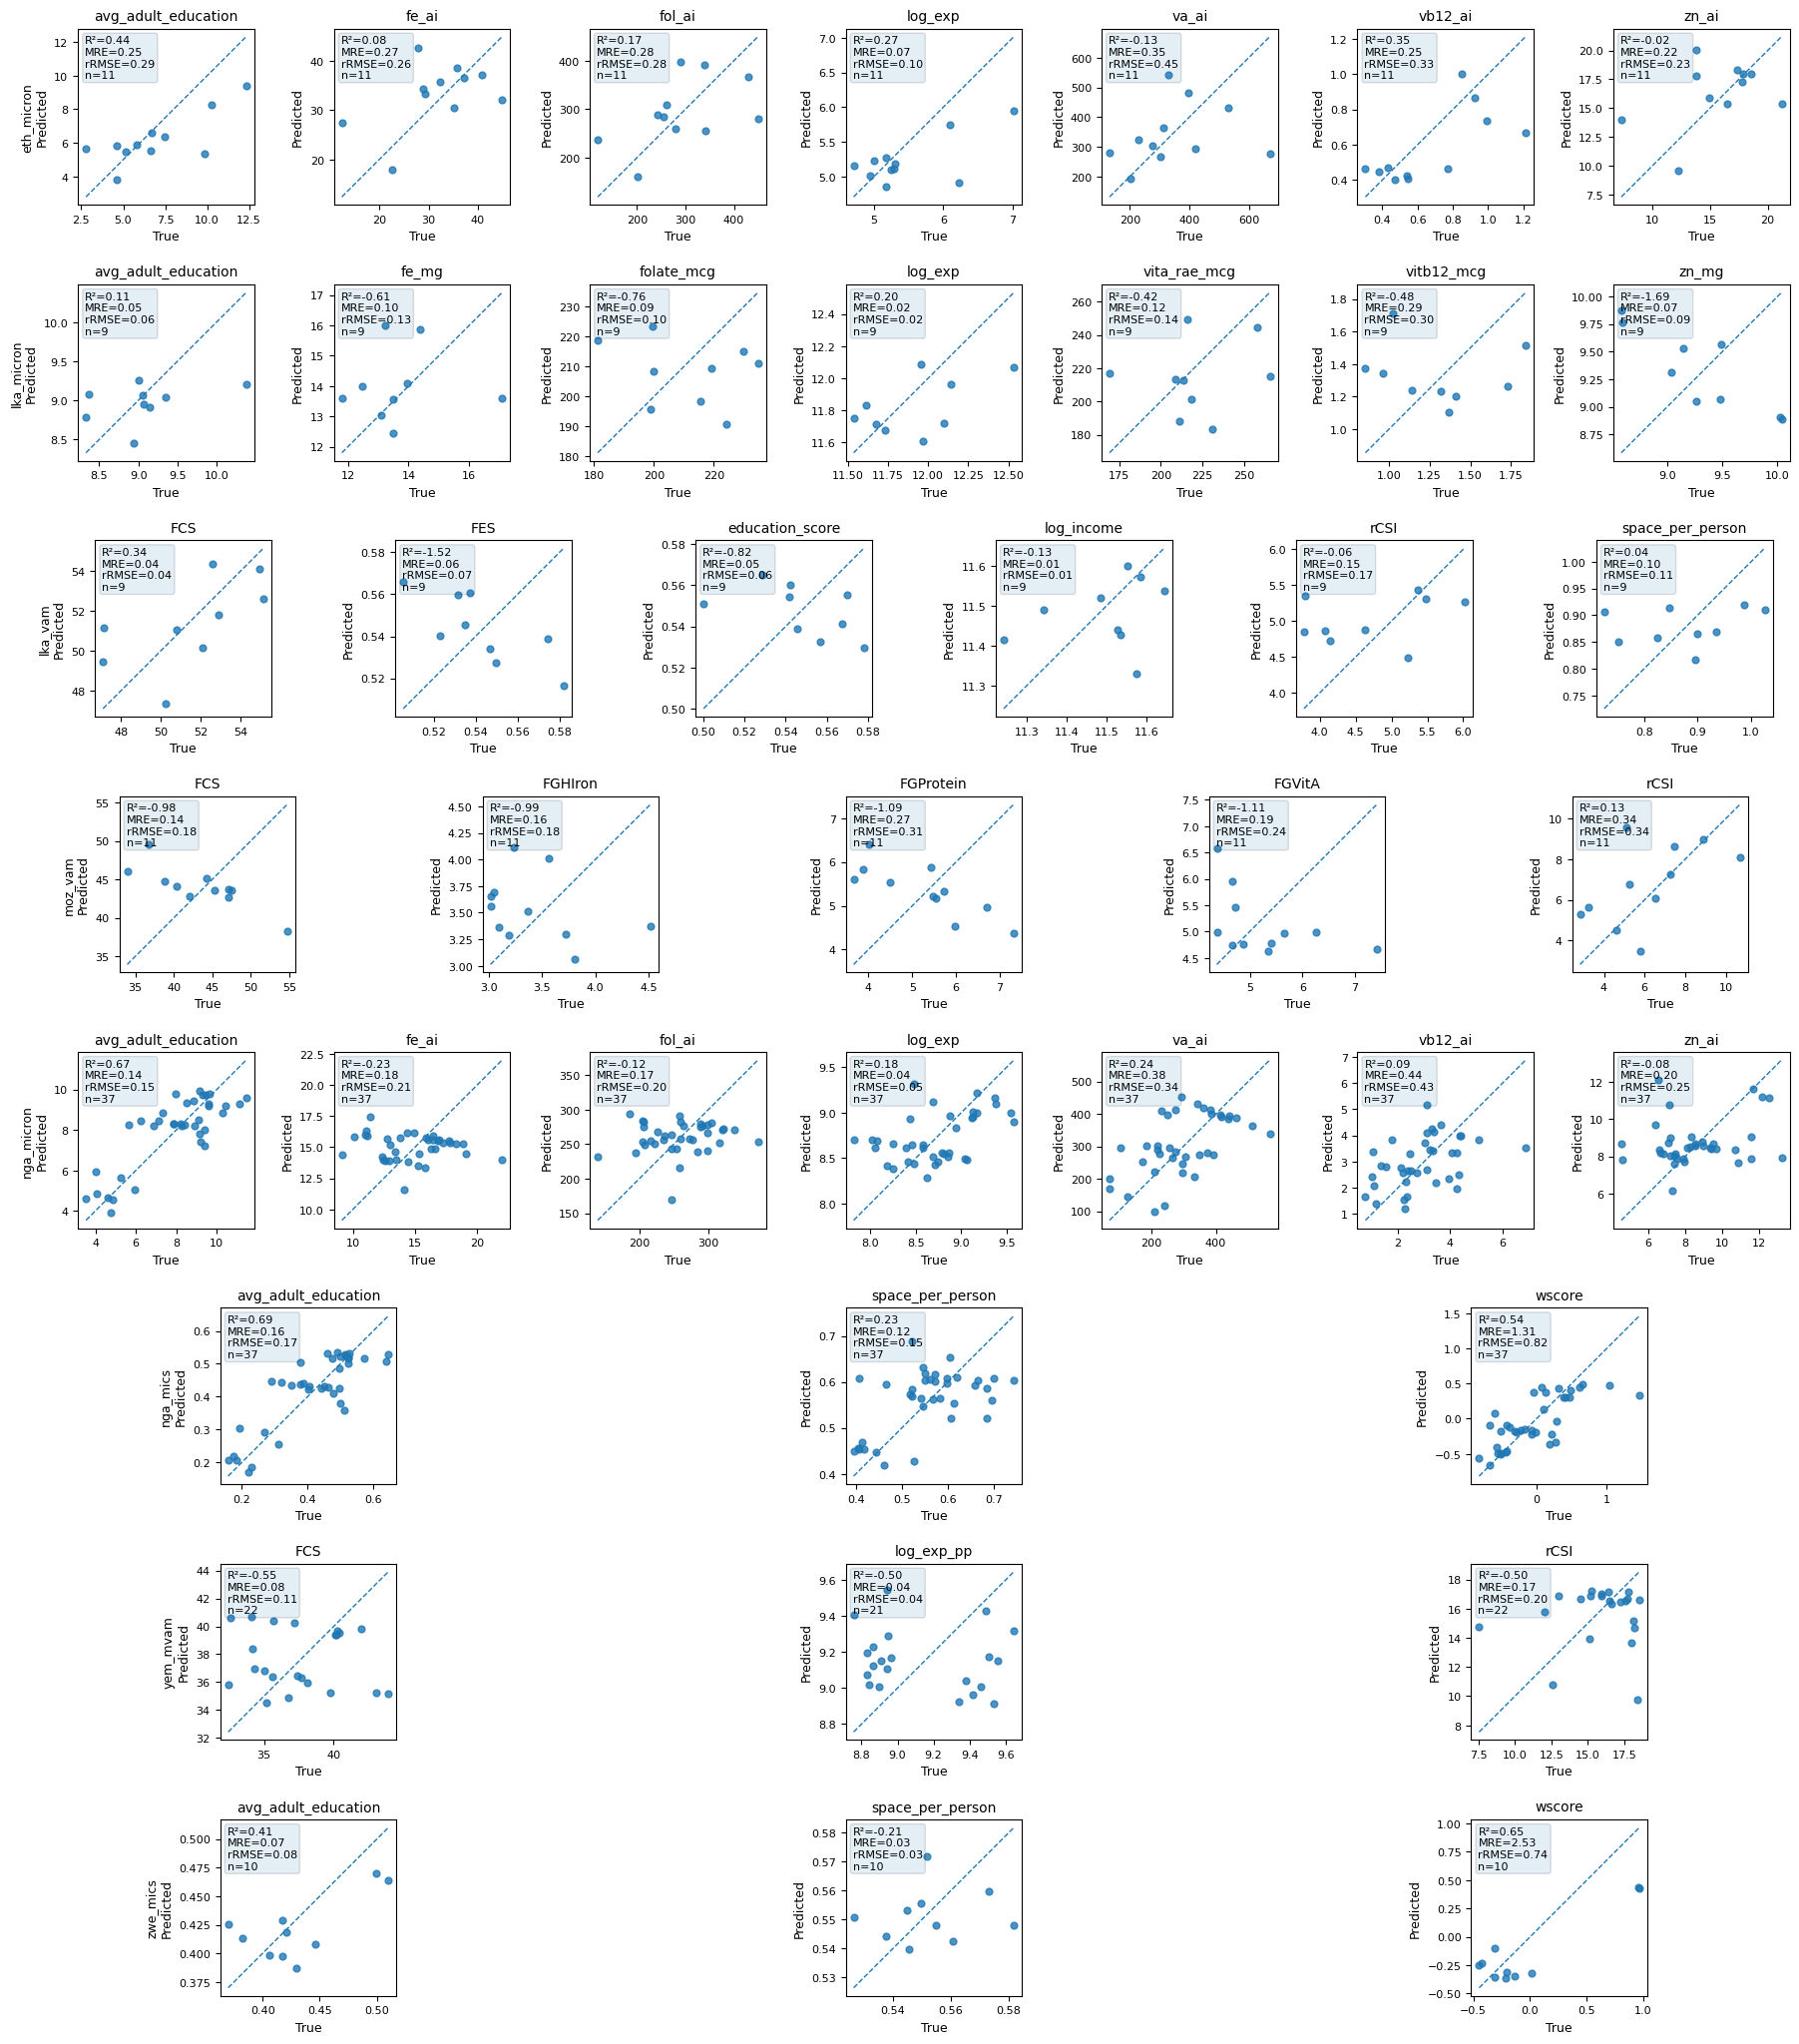

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

if results_df.empty or loo_pred_df.empty:
    print("No results to plot.")
else:
    experiments = list(results_df["experiment_id"].dropna().unique())

    targets_by_experiment = {
        exp: list(
            results_df.loc[results_df["experiment_id"] == exp, "target"]
            .dropna()
            .sort_values()
            .unique()
        )
        for exp in experiments
    }

    max_cols = max(len(tgts) for tgts in targets_by_experiment.values())
    n_rows = len(experiments)

    fig = plt.figure(figsize=(3.2 * max_cols, 3.2 * n_rows))
    outer = GridSpec(n_rows, 1, figure=fig, hspace=0.45)

    for i, experiment_id in enumerate(experiments):
        row_targets = targets_by_experiment[experiment_id]
        inner = outer[i].subgridspec(1, len(row_targets), wspace=0.3)

        for j, target_name in enumerate(row_targets):
            ax = fig.add_subplot(inner[0, j])

            pred_sub = loo_pred_df[
                (loo_pred_df["experiment_id"] == experiment_id) &
                (loo_pred_df["target"] == target_name)
            ].copy()

            metric_sub = results_df[
                (results_df["experiment_id"] == experiment_id) &
                (results_df["target"] == target_name)
            ].copy()

            if pred_sub.empty or metric_sub.empty:
                ax.axis("off")
                continue

            y_true = pred_sub["y_true"].to_numpy()
            y_pred = pred_sub["y_pred"].to_numpy()

            ax.scatter(y_true, y_pred, alpha=0.8, s=24)

            xy_min = min(np.min(y_true), np.min(y_pred))
            xy_max = max(np.max(y_true), np.max(y_pred))
            ax.plot([xy_min, xy_max], [xy_min, xy_max], linestyle="--", linewidth=1)

            row = metric_sub.iloc[0]
            r2 = row["r2"]
            mre = row["mre"]
            rrmse = row["rrmse"]
            n = row["n_adm1"]

            ax.text(
                0.04, 0.96,
                f"R²={r2:.2f}\nMRE={mre:.2f}\nrRMSE={rrmse:.2f}\nn={n}",
                transform=ax.transAxes,
                va="top",
                ha="left",
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.22", alpha=0.12)
            )

            ax.set_title(str(target_name), fontsize=10, pad=6)

            if j == 0:
                ax.set_ylabel(f"{experiment_id}\nPredicted", fontsize=9)
            else:
                ax.set_ylabel("Predicted", fontsize=9)

            ax.set_xlabel("True", fontsize=9)
            ax.tick_params(axis="both", labelsize=8)

            # square subplot box, without forcing equal axis limits
            ax.set_box_aspect(1)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_658681/1778544346.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=1.2)


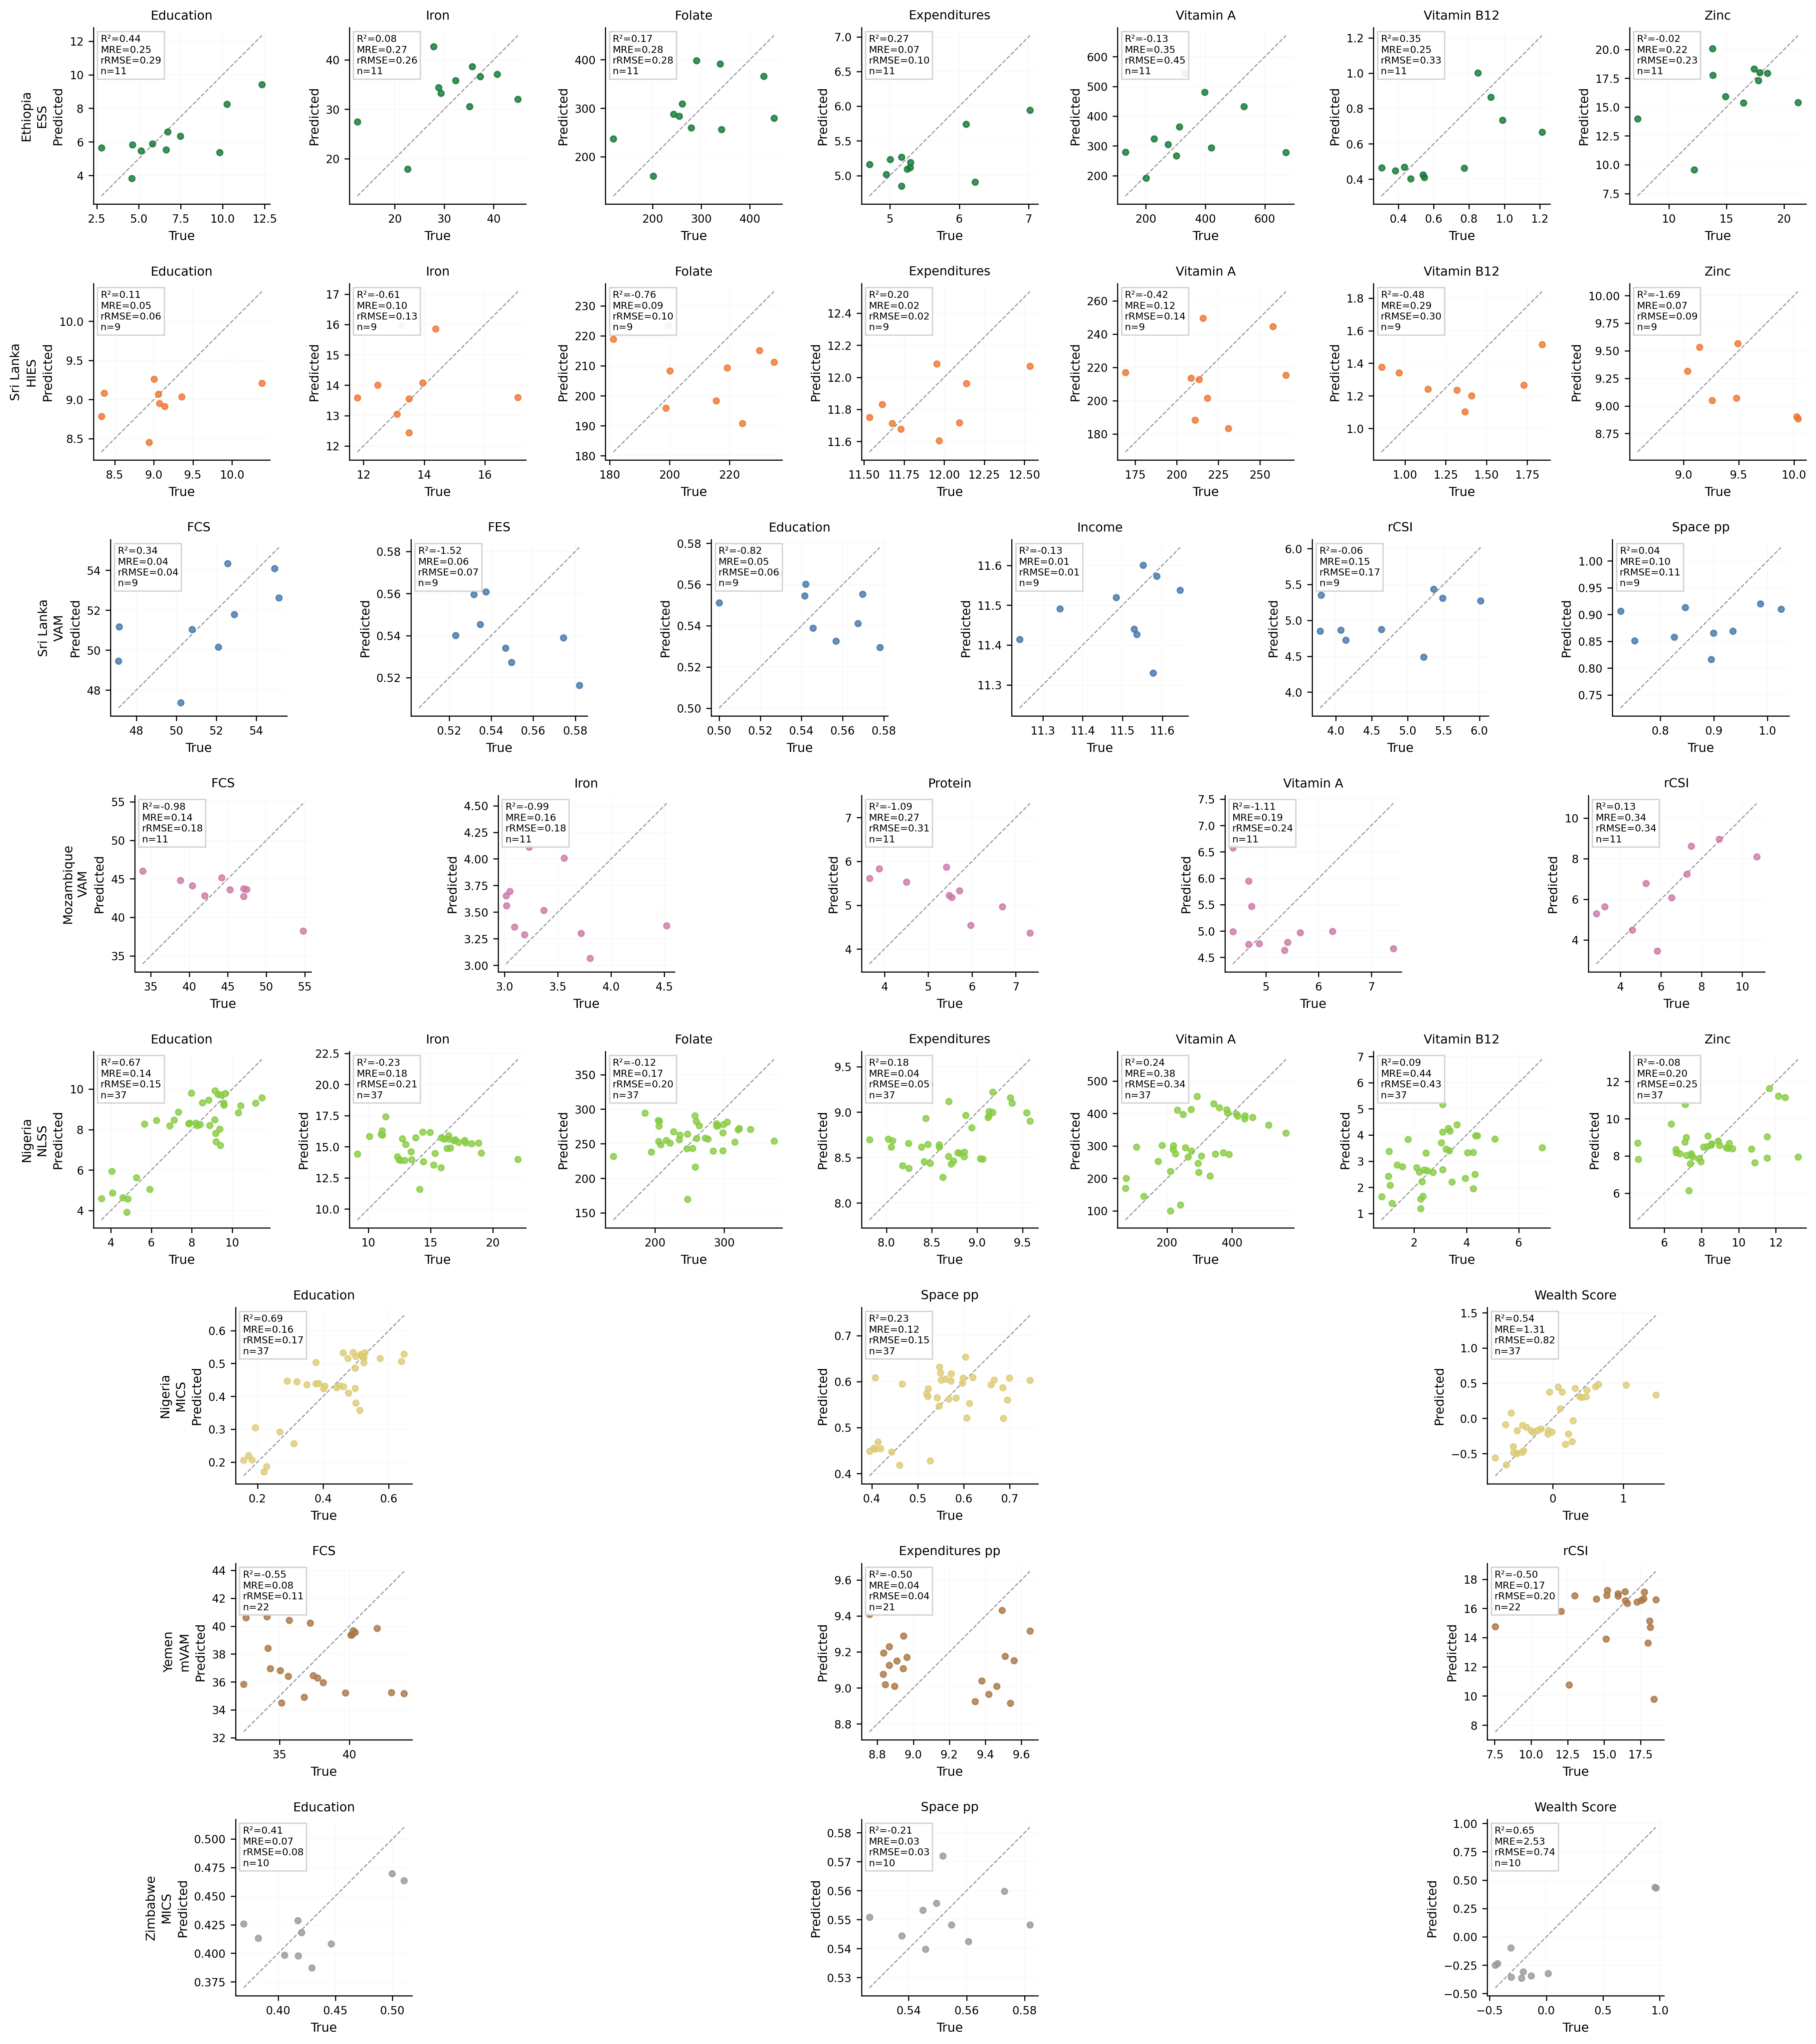

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from cycler import cycler

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

if results_df.empty or loo_pred_df.empty:
    print("No results to plot.")
else:
    experiments = list(results_df["experiment_id"].dropna().unique())
    targets_by_experiment = {
        exp: list(
            results_df.loc[results_df["experiment_id"] == exp, "target"]
            .dropna().sort_values().unique()
        )
        for exp in experiments
    }
    max_cols = max(len(tgts) for tgts in targets_by_experiment.values())
    n_rows = len(experiments)

    fig = plt.figure(figsize=(3.2 * max_cols, 3.2 * n_rows), dpi=300)
    outer = GridSpec(n_rows, 1, figure=fig, hspace=0.45)

    for i, experiment_id in enumerate(experiments):
        row_targets = targets_by_experiment[experiment_id]
        inner = outer[i].subgridspec(1, len(row_targets), wspace=0.3)
        color = DATASET_COLORS.get(experiment_id, "#888888")

        for j, target_name in enumerate(row_targets):
            ax = fig.add_subplot(inner[0, j])

            pred_sub = loo_pred_df[
                (loo_pred_df["experiment_id"] == experiment_id) &
                (loo_pred_df["target"] == target_name)
            ].copy()
            metric_sub = results_df[
                (results_df["experiment_id"] == experiment_id) &
                (results_df["target"] == target_name)
            ].copy()

            if pred_sub.empty or metric_sub.empty:
                ax.axis("off")
                continue

            y_true = pred_sub["y_true"].to_numpy()
            y_pred = pred_sub["y_pred"].to_numpy()

            ax.scatter(y_true, y_pred, alpha=0.8, s=18, color=color, zorder=2)

            xy_min = min(np.min(y_true), np.min(y_pred))
            xy_max = max(np.max(y_true), np.max(y_pred))
            ax.plot([xy_min, xy_max], [xy_min, xy_max],
                    linestyle="--", linewidth=0.8, color="#555555", alpha=0.6, zorder=1)

            ax.grid(True, alpha=0.12, linewidth=0.4)

            row = metric_sub.iloc[0]
            ax.text(
                0.04, 0.96,
                f"R²={row['r2']:.2f}\nMRE={row['mre']:.2f}\nrRMSE={row['rrmse']:.2f}\nn={int(row['n_adm1'])}",
                transform=ax.transAxes, va="top", ha="left", fontsize=7,
                bbox=dict(boxstyle="square,pad=0.3", fc="white", alpha=0.92, ec="0.82"),
            )

            ax.set_title(
                DISPLAY_LABELS.get(target_name, target_name),
                fontsize=9, pad=6
            )
            if j == 0:
                ax.set_ylabel(
                    f"{DISPLAY_LABELS.get(experiment_id, experiment_id)}\nPredicted",
                    fontsize=9, linespacing=1.4
                )
            else:
                ax.set_ylabel("Predicted", fontsize=9)
            ax.set_xlabel("True", fontsize=9)
            ax.set_box_aspect(1)

    fig.tight_layout(pad=1.2)
    plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/loo_scatter.pdf", bbox_inches="tight")
    plt.show()

In [14]:
metrics_with_context.head()

,seed,adm1_code,adm1_name,target,n_true,n_gen,n_nat,n_over,emd_gen,emd_nat,...,experiment_id,r3q_1,rfh_avg_1,vim_avg_1,entropy_1,rwi_1,entropy_2,wscore_1,target_value,improvement
0,1,Central,Central,vita_rae_mcg,2521,2521,77,2521,0.261724,0.175869,...,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,215.800688,-0.085854
1,1,Central,Central,folate_mcg,2521,2521,77,2521,0.464382,0.121110,...,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,199.653885,-0.343272
2,1,Central,Central,vitb12_mcg,2521,2521,77,2521,0.386113,0.327010,...,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,0.963774,-0.059103
3,1,Central,Central,fe_mg,2521,2521,77,2521,0.173448,0.231343,...,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,11.801965,0.057894
4,1,Central,Central,zn_mg,2521,2521,77,2521,0.421575,0.375283,...,lka_micron,106.063865,60.416653,0.77727,4.49086,0.239988,NaN,NaN,8.582747,-0.046292


In [15]:
metrics_with_context.columns

Index(['seed', 'adm1_code', 'adm1_name', 'target', 'n_true', 'n_gen', 'n_nat',
       'n_over', 'emd_gen', 'emd_nat', 'emd_over', 'variability_intrinsic',
       'absmeanerr_gen', 'absmeanerr_nat', 'absmeanerr_over', 'country',
       'dataset', 'train_percent_int', 'experiment_id', 'r3q_1', 'rfh_avg_1',
       'vim_avg_1', 'entropy_1', 'rwi_1', 'entropy_2', 'wscore_1',
       'target_value', 'improvement'],
      dtype='object')

,experiment_id,target,emd_gen_mean,emd_gen_std,r2,rrmse,n_adm1_x,n_adm1_y
0,eth_micron,avg_adult_education,0.325904,0.187615,0.443777,0.293033,11,11
1,eth_micron,fe_ai,0.390958,0.248409,0.076465,0.259262,11,11
2,eth_micron,fol_ai,0.449282,0.344493,0.172548,0.284134,11,11
3,eth_micron,log_exp,0.326498,0.261200,0.267261,0.102653,11,11
4,eth_micron,va_ai,0.642691,0.591019,-0.127481,0.451513,11,11
5,eth_micron,vb12_ai,0.619116,0.560517,0.346114,0.332375,11,11
6,eth_micron,zn_ai,0.408559,0.246405,-0.015063,0.232060,11,11
7,lka_micron,avg_adult_education,0.274733,0.127118,0.105353,0.058902,9,9
8,lka_micron,fe_mg,0.341733,0.202459,-0.612040,0.130393,9,9
9,lka_micron,folate_mcg,0.320143,0.141104,-0.759254,0.103848,9,9


Correlations with emd_gen_mean (std across adm1 retained)
r2    vs emd_gen_mean: Pearson=-0.421, Spearman=-0.507, Weighted Pearson=-0.591
rrmse vs emd_gen_mean: Pearson=-0.225, Spearman=-0.105, Weighted Pearson=-0.560


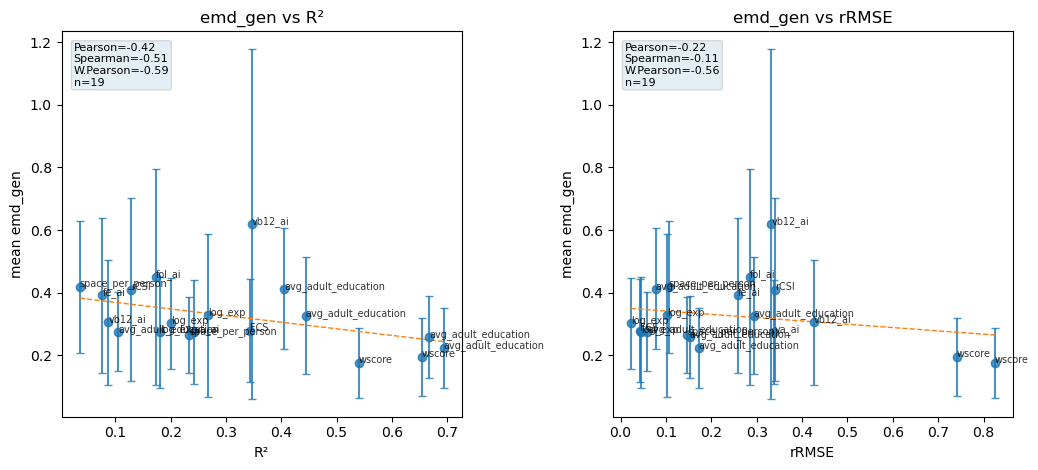

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Aggregate emd_gen at the same level as results_df
# ---------------------------------------------------
emd_df = (
    metrics_with_context
    .groupby(["experiment_id", "target"], as_index=False)
    .agg(
        emd_gen_mean=("emd_gen", "mean"),
        emd_gen_std=("emd_gen", "std"),
        emd_gen_median=("emd_gen", "median"),
        n_adm1=("adm1_name", "nunique")
    )
)

# if a group has only one adm1, std becomes NaN; replace with 0 for plotting
emd_df["emd_gen_std"] = emd_df["emd_gen_std"].fillna(0.0)

# ---------------------------------------------------
# 2. Merge with regression results
# ---------------------------------------------------
corr_df = results_df.merge(
    emd_df,
    on=["experiment_id", "target"],
    how="inner"
).copy()

corr_df = corr_df.replace([np.inf, -np.inf], np.nan)
corr_df = corr_df.dropna(subset=["emd_gen_mean", "emd_gen_std", "r2", "rrmse"])

display(
    corr_df[
        ["experiment_id", "target", "emd_gen_mean", "emd_gen_std", "r2", "rrmse", "n_adm1_x", "n_adm1_y"]
        if "n_adm1_x" in corr_df.columns else
        ["experiment_id", "target", "emd_gen_mean", "emd_gen_std", "r2", "rrmse"]
    ].sort_values(["experiment_id", "target"])
)

# ---------------------------------------------------
# 3. Weighted Pearson helper
#    weights from emd_gen uncertainty: w = 1 / std^2
# ---------------------------------------------------
def weighted_pearson(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]

    if len(x) < 2:
        return np.nan

    wx = np.sum(w * x) / np.sum(w)
    wy = np.sum(w * y) / np.sum(w)

    cov_xy = np.sum(w * (x - wx) * (y - wy)) / np.sum(w)
    var_x = np.sum(w * (x - wx) ** 2) / np.sum(w)
    var_y = np.sum(w * (y - wy) ** 2) / np.sum(w)

    if var_x <= 0 or var_y <= 0:
        return np.nan

    return cov_xy / np.sqrt(var_x * var_y)

# use inverse-variance style weights
# add epsilon so std=0 does not explode
eps = 1e-8
corr_df["weight_from_emd_std"] = 1.0 / (corr_df["emd_gen_std"] ** 2 + eps)
corr_df = corr_df[corr_df["r2"] > 0] 

# ---------------------------------------------------
# 4. Correlations
# ---------------------------------------------------
# r2 vs emd_gen_mean
pearson_r2 = corr_df["r2"].corr(corr_df["emd_gen_mean"], method="pearson")
spearman_r2 = corr_df["r2"].corr(corr_df["emd_gen_mean"], method="spearman")
wpearson_r2 = weighted_pearson(
    corr_df["r2"],
    corr_df["emd_gen_mean"],
    corr_df["weight_from_emd_std"]
)

# rrmse vs emd_gen_mean
pearson_rrmse = corr_df["rrmse"].corr(corr_df["emd_gen_mean"], method="pearson")
spearman_rrmse = corr_df["rrmse"].corr(corr_df["emd_gen_mean"], method="spearman")
wpearson_rrmse = weighted_pearson(
    corr_df["rrmse"],
    corr_df["emd_gen_mean"],
    corr_df["weight_from_emd_std"]
)

print("Correlations with emd_gen_mean (std across adm1 retained)")
print(f"r2    vs emd_gen_mean: Pearson={pearson_r2:.3f}, Spearman={spearman_r2:.3f}, Weighted Pearson={wpearson_r2:.3f}")
print(f"rrmse vs emd_gen_mean: Pearson={pearson_rrmse:.3f}, Spearman={spearman_rrmse:.3f}, Weighted Pearson={wpearson_rrmse:.3f}")

# ---------------------------------------------------
# 5. Plot with inverted axes:
#    x = metric, y = emd_gen_mean
#    y-errorbars = emd_gen_std
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

# -------- Plot 1: x=r2, y=emd_gen_mean
ax = axes[0]
x = corr_df["r2"].to_numpy()
y = corr_df["emd_gen_mean"].to_numpy()
yerr = corr_df["emd_gen_std"].to_numpy()

ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", alpha=0.8, capsize=3
)

if len(corr_df) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=1)

for _, row in corr_df.iterrows():
    ax.annotate(
        row["target"],
        (row["r2"], row["emd_gen_mean"]),
        fontsize=7,
        alpha=0.8
    )

ax.set_title("emd_gen vs R²")
ax.set_xlabel("R²")
ax.set_ylabel("mean emd_gen")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson_r2:.2f}\nSpearman={spearman_r2:.2f}\nW.Pearson={wpearson_r2:.2f}\nn={len(corr_df)}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.2", alpha=0.12)
)

# -------- Plot 2: x=rrmse, y=emd_gen_mean
ax = axes[1]
x = corr_df["rrmse"].to_numpy()
y = corr_df["emd_gen_mean"].to_numpy()
yerr = corr_df["emd_gen_std"].to_numpy()

ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", alpha=0.8, capsize=3
)

if len(corr_df) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=1)

for _, row in corr_df.iterrows():
    ax.annotate(
        row["target"],
        (row["rrmse"], row["emd_gen_mean"]),
        fontsize=7,
        alpha=0.8
    )

ax.set_title("emd_gen vs rRMSE")
ax.set_xlabel("rRMSE")
ax.set_ylabel("mean emd_gen")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson_rrmse:.2f}\nSpearman={spearman_rrmse:.2f}\nW.Pearson={wpearson_rrmse:.2f}\nn={len(corr_df)}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.2", alpha=0.12)
)

plt.tight_layout()
plt.show()

,experiment_id,target,absmeanerr_gen_mean,absmeanerr_gen_std,r2,rrmse
0,eth_micron,avg_adult_education,0.686541,0.566506,0.443777,0.293033
1,eth_micron,fe_ai,0.854727,0.657641,0.076465,0.259262
2,eth_micron,fol_ai,0.905264,0.803039,0.172548,0.284134
3,eth_micron,log_exp,0.791942,0.796639,0.267261,0.102653
4,eth_micron,va_ai,0.951564,0.916546,-0.127481,0.451513
5,eth_micron,vb12_ai,1.354555,0.953598,0.346114,0.332375
6,eth_micron,zn_ai,0.938644,0.679720,-0.015063,0.232060
7,lka_micron,avg_adult_education,1.483281,0.985482,0.105353,0.058902
8,lka_micron,fe_mg,0.900779,0.818994,-0.612040,0.130393
9,lka_micron,folate_mcg,1.316933,0.820819,-0.759254,0.103848


Correlations with absmeanerr_gen_mean (std across adm1 retained)
r2    vs absmeanerr_gen_mean: Pearson=-0.539, Spearman=-0.596, Weighted Pearson=-0.664
rrmse vs absmeanerr_gen_mean: Pearson=-0.554, Spearman=-0.593, Weighted Pearson=-0.699


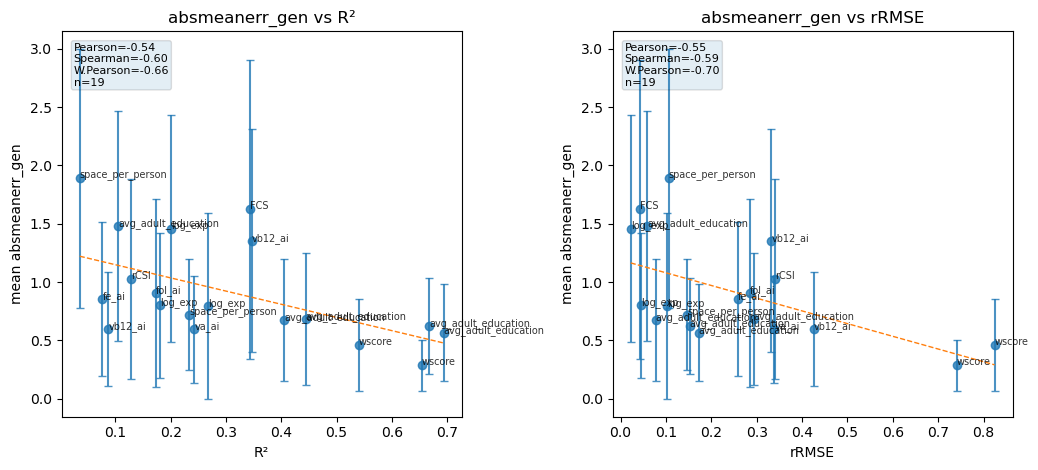

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. Aggregate absmeanerr_gen at the same level as results_df
# ---------------------------------------------------
agg_df = (
    metrics_with_context
    .groupby(["experiment_id", "target"], as_index=False)
    .agg(
        absmeanerr_gen_mean=("absmeanerr_gen", "mean"),
        absmeanerr_gen_std=("absmeanerr_gen", "std"),
        absmeanerr_gen_median=("absmeanerr_gen", "median"),
        n_adm1=("adm1_name", "nunique")
    )
)

agg_df["absmeanerr_gen_std"] = agg_df["absmeanerr_gen_std"].fillna(0.0)

# ---------------------------------------------------
# 2. Merge with regression results
# ---------------------------------------------------
corr_df = results_df.merge(
    agg_df,
    on=["experiment_id", "target"],
    how="inner"
).copy()

corr_df = corr_df.replace([np.inf, -np.inf], np.nan)
corr_df = corr_df.dropna(subset=["absmeanerr_gen_mean", "absmeanerr_gen_std", "r2", "rrmse"])

display(
    corr_df[
        ["experiment_id", "target", "absmeanerr_gen_mean", "absmeanerr_gen_std", "r2", "rrmse"]
    ].sort_values(["experiment_id", "target"])
)

# ---------------------------------------------------
# 3. Weighted Pearson helper
# ---------------------------------------------------
def weighted_pearson(x, y, w):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & np.isfinite(w) & (w > 0)
    x, y, w = x[mask], y[mask], w[mask]

    if len(x) < 2:
        return np.nan

    wx = np.sum(w * x) / np.sum(w)
    wy = np.sum(w * y) / np.sum(w)

    cov_xy = np.sum(w * (x - wx) * (y - wy)) / np.sum(w)
    var_x = np.sum(w * (x - wx) ** 2) / np.sum(w)
    var_y = np.sum(w * (y - wy) ** 2) / np.sum(w)

    if var_x <= 0 or var_y <= 0:
        return np.nan

    return cov_xy / np.sqrt(var_x * var_y)

eps = 1e-8
corr_df["weight_from_absmeanerr_std"] = 1.0 / (corr_df["absmeanerr_gen_std"] ** 2 + eps)
corr_df = corr_df[corr_df["r2"] > 0] 

# ---------------------------------------------------
# 4. Correlations
# ---------------------------------------------------
pearson_r2 = corr_df["r2"].corr(corr_df["absmeanerr_gen_mean"], method="pearson")
spearman_r2 = corr_df["r2"].corr(corr_df["absmeanerr_gen_mean"], method="spearman")
wpearson_r2 = weighted_pearson(
    corr_df["r2"],
    corr_df["absmeanerr_gen_mean"],
    corr_df["weight_from_absmeanerr_std"]
)

pearson_rrmse = corr_df["rrmse"].corr(corr_df["absmeanerr_gen_mean"], method="pearson")
spearman_rrmse = corr_df["rrmse"].corr(corr_df["absmeanerr_gen_mean"], method="spearman")
wpearson_rrmse = weighted_pearson(
    corr_df["rrmse"],
    corr_df["absmeanerr_gen_mean"],
    corr_df["weight_from_absmeanerr_std"]
)

print("Correlations with absmeanerr_gen_mean (std across adm1 retained)")
print(f"r2    vs absmeanerr_gen_mean: Pearson={pearson_r2:.3f}, Spearman={spearman_r2:.3f}, Weighted Pearson={wpearson_r2:.3f}")
print(f"rrmse vs absmeanerr_gen_mean: Pearson={pearson_rrmse:.3f}, Spearman={spearman_rrmse:.3f}, Weighted Pearson={wpearson_rrmse:.3f}")

# ---------------------------------------------------
# 5. Plot with inverted axes:
#    x = metric, y = absmeanerr_gen_mean
#    y-errorbars = absmeanerr_gen_std
# ---------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

# -------- Plot 1: x=r2, y=absmeanerr_gen_mean
ax = axes[0]
x = corr_df["r2"].to_numpy()
y = corr_df["absmeanerr_gen_mean"].to_numpy()
yerr = corr_df["absmeanerr_gen_std"].to_numpy()

ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", alpha=0.8, capsize=3
)

if len(corr_df) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=1)

for _, row in corr_df.iterrows():
    ax.annotate(
        row["target"],
        (row["r2"], row["absmeanerr_gen_mean"]),
        fontsize=7,
        alpha=0.8
    )

ax.set_title("absmeanerr_gen vs R²")
ax.set_xlabel("R²")
ax.set_ylabel("mean absmeanerr_gen")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson_r2:.2f}\nSpearman={spearman_r2:.2f}\nW.Pearson={wpearson_r2:.2f}\nn={len(corr_df)}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.2", alpha=0.12)
)

# -------- Plot 2: x=rrmse, y=absmeanerr_gen_mean
ax = axes[1]
x = corr_df["rrmse"].to_numpy()
y = corr_df["absmeanerr_gen_mean"].to_numpy()
yerr = corr_df["absmeanerr_gen_std"].to_numpy()

ax.errorbar(
    x, y, yerr=yerr,
    fmt="o", alpha=0.8, capsize=3
)

if len(corr_df) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=1)

for _, row in corr_df.iterrows():
    ax.annotate(
        row["target"],
        (row["rrmse"], row["absmeanerr_gen_mean"]),
        fontsize=7,
        alpha=0.8
    )

ax.set_title("absmeanerr_gen vs rRMSE")
ax.set_xlabel("rRMSE")
ax.set_ylabel("mean absmeanerr_gen")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson_rrmse:.2f}\nSpearman={spearman_rrmse:.2f}\nW.Pearson={wpearson_rrmse:.2f}\nn={len(corr_df)}",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=8,
    bbox=dict(boxstyle="round,pad=0.2", alpha=0.12)
)

plt.tight_layout()
plt.show()

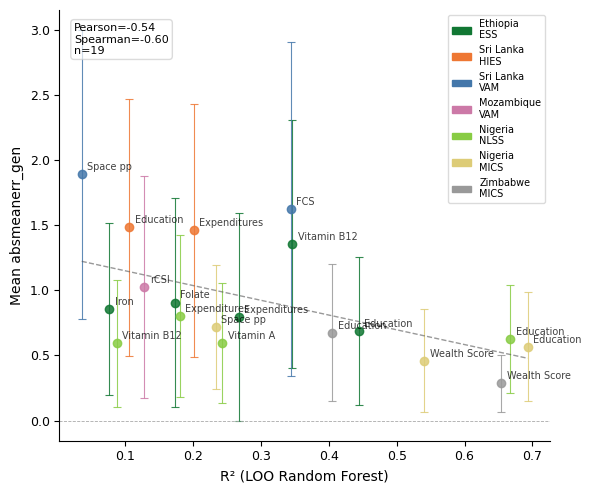

In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

DISPLAY_LABELS = {
    "avg_adult_education": "Education", "fe_ai": "Iron", "fol_ai": "Folate",
    "log_exp": "Expenditures", "va_ai": "Vitamin A", "vb12_ai": "Vitamin B12",
    "zn_ai": "Zinc", "fe_mg": "Iron", "folate_mcg": "Folate",
    "vita_rae_mcg": "Vitamin A", "vitb12_mcg": "Vitamin B12", "zn_mg": "Zinc",
    "FCS": "FCS", "FES": "FES", "education_score": "Education",
    "log_income": "Income", "rCSI": "rCSI", "space_per_person": "Space pp",
    "FGHIron": "Iron", "FGProtein": "Protein", "FGVitA": "Vitamin A",
    "wscore": "Wealth Score", "log_exp_pp": "Expenditures pp",
    "eth_micron": "Ethiopia\nESS", "lka_micron": "Sri Lanka\nHIES",
    "lka_vam": "Sri Lanka\nVAM", "moz_vam": "Mozambique\nVAM",
    "nga_micron": "Nigeria\nNLSS", "nga_mics": "Nigeria\nMICS",
    "yem_mvam": "Yemen\nmVAM", "zwe_mics": "Zimbabwe\nMICS",
}

DATASET_COLORS = {
    "eth_micron": "#117733", "lka_micron": "#EE7733", "lka_vam": "#4477AA",
    "moz_vam": "#CC79A7", "nga_micron": "#88CC44", "nga_mics": "#DDCC77",
    "yem_mvam": "#AA7744", "zwe_mics": "#999999",
}

plot_df = corr_df[corr_df["r2"] > 0].copy()

fig, ax = plt.subplots(figsize=(6, 5))

for _, row in plot_df.iterrows():
    color = DATASET_COLORS.get(row["experiment_id"], "#888888")
    ax.errorbar(
        row["r2"], row["absmeanerr_gen_mean"],
        yerr=row["absmeanerr_gen_std"],
        fmt="o", color=color, alpha=0.85,
        capsize=3, capthick=0.8, elinewidth=0.8, markersize=6,
    )
    ax.annotate(
        DISPLAY_LABELS.get(row["target"], row["target"]),
        (row["r2"], row["absmeanerr_gen_mean"]),
        fontsize=7, alpha=0.75, xytext=(4, 3), textcoords="offset points",
    )

# regression line
x = plot_df["r2"].values
y = plot_df["absmeanerr_gen_mean"].values
if len(x) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=1, color="#555555", alpha=0.6)

# stats box
pearson  = plot_df["r2"].corr(plot_df["absmeanerr_gen_mean"], method="pearson")
spearman = plot_df["r2"].corr(plot_df["absmeanerr_gen_mean"], method="spearman")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson:.2f}\nSpearman={spearman:.2f}\nn={len(plot_df)}",
    transform=ax.transAxes, va="top", ha="left", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="#cccccc"),
)

# legend
legend_handles = [
    mpatches.Patch(color=color, label=DISPLAY_LABELS.get(exp, exp))
    for exp, color in DATASET_COLORS.items()
    if exp in plot_df["experiment_id"].values
]
ax.legend(
    handles=legend_handles, fontsize=7,
    loc="upper right", framealpha=0.7, edgecolor="#cccccc",
)

ax.set_xlabel("R² (LOO Random Forest)", fontsize=10)
ax.set_ylabel("Mean absmeanerr_gen", fontsize=10)
ax.axhline(0, color="#aaaaaa", linewidth=0.6, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

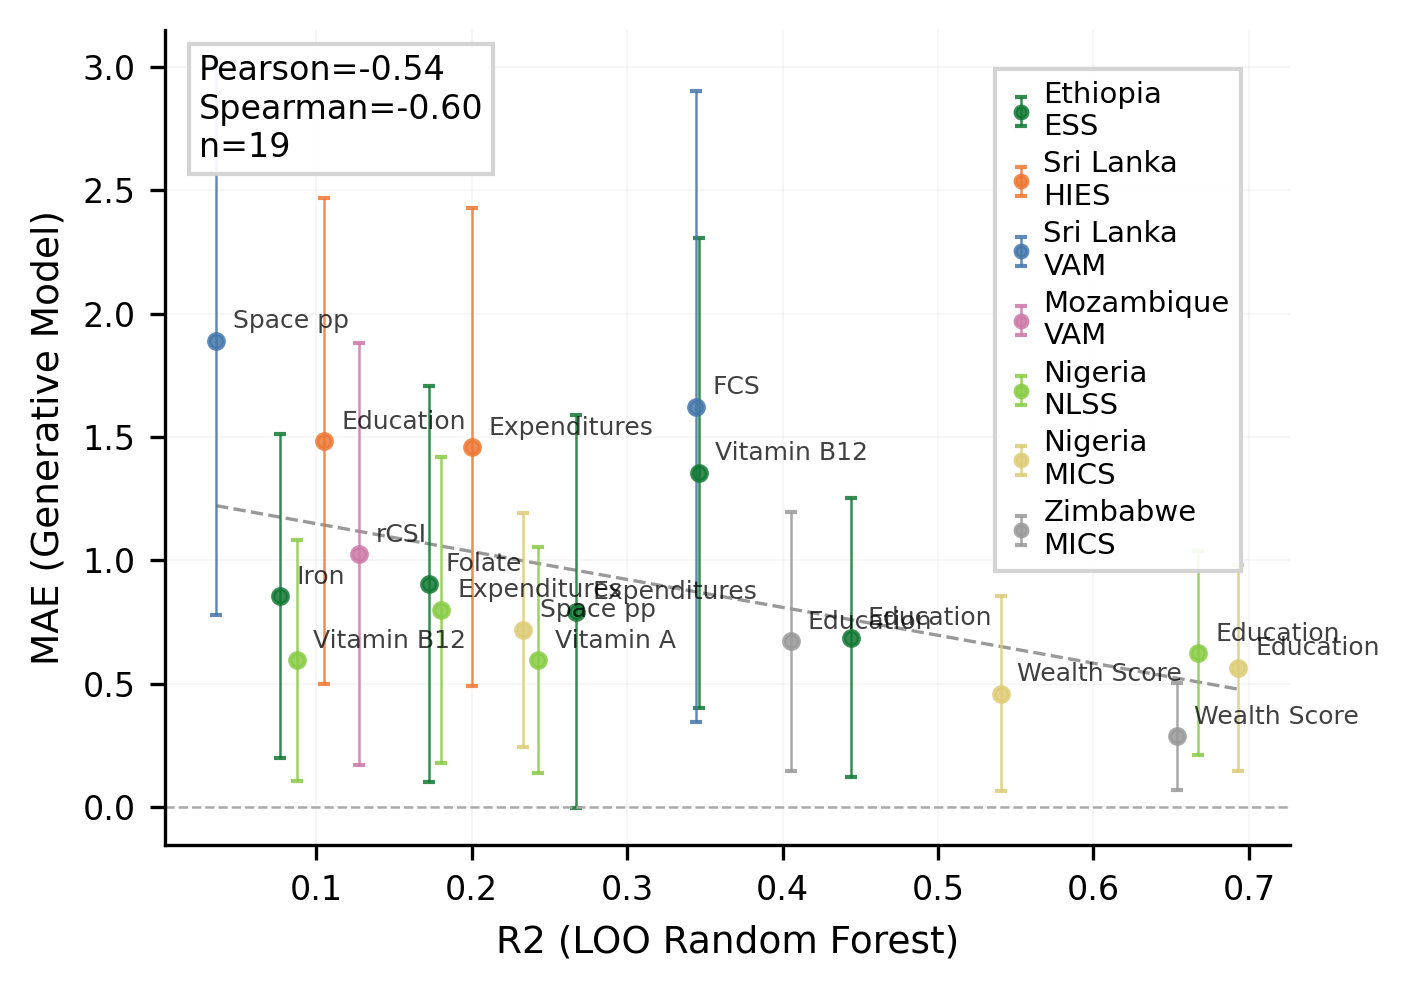

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

plot_df = corr_df[corr_df["r2"] > 0].copy()

fig, ax = plt.subplots(figsize=(4.8, 3.4), dpi=300)

for exp_id in sorted(plot_df["experiment_id"].unique()):
    d = plot_df[plot_df["experiment_id"] == exp_id]
    color = DATASET_COLORS.get(exp_id, "#888888")
    ax.errorbar(
        d["r2"], d["absmeanerr_gen_mean"],
        yerr=d["absmeanerr_gen_std"],
        fmt="o", linestyle="none",
        color=color,
        markersize=3.5, alpha=0.85,
        elinewidth=0.6, capsize=1.5,
        zorder=2,
        label=DISPLAY_LABELS.get(exp_id, exp_id),
    )
    for _, row in d.iterrows():
        ax.annotate(
            DISPLAY_LABELS.get(row["target"], row["target"]),
            (row["r2"], row["absmeanerr_gen_mean"]),
            fontsize=6, alpha=0.75,
            xytext=(4, 3), textcoords="offset points",
        )

# regression line
x = plot_df["r2"].values
y = plot_df["absmeanerr_gen_mean"].values
if len(x) >= 2 and np.nanstd(x) > 0:
    m, b = np.polyfit(x, y, 1)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m * xline + b, linestyle="--", linewidth=0.8, color="#555555", alpha=0.6, zorder=1)

ax.axhline(0, color="#aaaaaa", linewidth=0.6, linestyle="--")
ax.grid(True, alpha=0.12, linewidth=0.4)

pearson  = plot_df["r2"].corr(plot_df["absmeanerr_gen_mean"], method="pearson")
spearman = plot_df["r2"].corr(plot_df["absmeanerr_gen_mean"], method="spearman")
ax.text(
    0.03, 0.97,
    f"Pearson={pearson:.2f}\nSpearman={spearman:.2f}\nn={len(plot_df)}",
    transform=ax.transAxes, va="top", ha="left", fontsize=8,
    bbox=dict(boxstyle="square,pad=0.3", fc="white", alpha=0.92, ec="0.82"),
)

ax.set_xlabel("R2 (LOO Random Forest)", linespacing=1.4)
ax.set_ylabel("MAE (Generative Model)", linespacing=1.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, labels,
    loc="upper right",
    bbox_to_anchor=(0.97, 0.97),
    ncol=1, frameon=True, framealpha=0.92,
    edgecolor="0.82", fancybox=False,
    fontsize=7, handlelength=1.0,
    handletextpad=0.25, labelspacing=0.32,
    borderpad=0.4, markerscale=0.8,
)

fig.tight_layout(pad=1.2)
plt.savefig("/data/shared/fsibilla/clean_code/Q1/R2/r2_vs_absmeanerr.pdf", bbox_inches="tight")
plt.show()